# (17) poisson simulation

**Motivation**: a simulation. host = ```any```, device = ```cuda:3``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.fighelper import *
from vae.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from analysis.chosen import *
from figures.analysis import *
from figures.imgs import plot_weights

device_idx = 3
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:3  ———  host: mach

In [3]:
phi = torch.randn((256, 512)) * 12e-3
rate = torch.randn(512) + 3
rate = torch.maximum(rate, torch.tensor(1e-3))

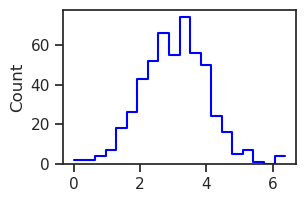

In [4]:
histplot(rate, color='b');

In [5]:
num = int(1e6)
samples = torch.empty((num, len(phi)))

for i in tqdm(range(num)):
    z = torch.poisson(rate)
    lamb = torch.exp(phi @ z)
    x = torch.poisson(lamb)
    samples[i] = x

samples.shape

100%|██████████████████████████████| 1000000/1000000 [01:03<00:00, 15849.81it/s]


torch.Size([1000000, 256])

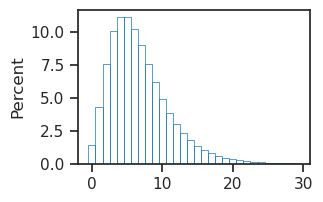

In [22]:
a = 30
bins = np.linspace(0, a, a + 1) - 0.5
histplot(samples[:, 3], element='bars', stat='percent', bins=bins);

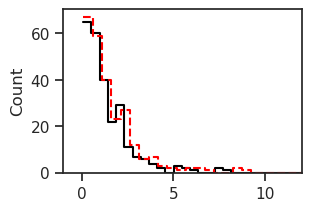

In [24]:
marginal_rates_theory = torch.exp(phi @ rate)
marginal_rates_empirical = samples.mean(0)

fig, ax = create_figure()
histplot(marginal_rates_theory, color='k')
histplot(marginal_rates_empirical, color='r', ls='--')
ax.set(xlim=(-1, 12))
plt.show()

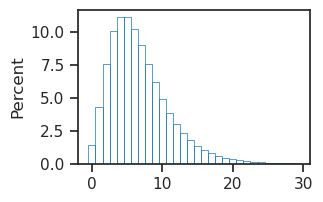

In [25]:
a = 30
pixel_i = 3

bins = np.linspace(0, a, a + 1) - 0.5
histplot(samples[:, pixel_i], element='bars', stat='percent', bins=bins);

In [26]:
def poisson_pdf(rate, max_x=20):
    xs = np.arange(0, max_x + 1)
    pmf = sp_stats.poisson.pmf(xs, rate)
    return xs, pmf

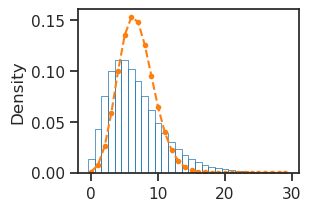

In [31]:
a = 30
pixel_i = 3
xs, ys = poisson_pdf(
    rate=marginal_rates_empirical[pixel_i].item(),
    max_x=200,
)

fig, ax = create_figure()
bins = np.linspace(0, a, a + 1) - 0.5
histplot(samples[:, pixel_i], element='bars', stat='density', bins=bins, ax=ax)
ax.plot(xs[:a], ys[:a], marker='.', ls='--')
plt.show()

In [32]:
mu = samples.mean(0)
var = samples.var(0)

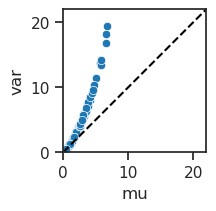

In [45]:
fig, ax = create_figure()

xs = np.linspace(0, mu.max().item())
ax.plot(xs, xs, color='k', ls='--')

sns.scatterplot(x=tonp(mu), y=tonp(var))

ax.set(
    xlim=(0, 22), ylim=(0, 22),
    xlabel='mu', ylabel='var',
)
ax_square(ax)
plt.show()